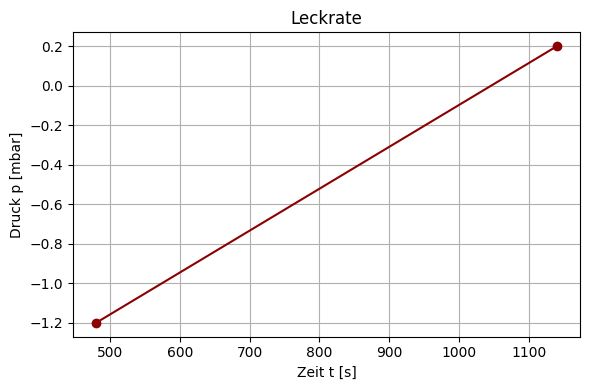

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# Daten aus Excel-Datei einlesen
# ===============================
# Spalte C: 12 Werte ab Zeile 7
col_C = pd.read_excel("Exp7_Dampfdruckkurve_p(T)_Template_2025.xlsx",
                      engine="openpyxl",
                      usecols="C",
                      skiprows=6,
                      nrows=13)

# Spalte I: 2 Werte ab Zeile 7
col_I = pd.read_excel("Exp7_Dampfdruckkurve_p(T)_Template_2025.xlsx",
                      engine="openpyxl",
                      usecols="I",
                      skiprows=6,
                      nrows=2)

# ===============================
# Spalten benennen und kürzen
# ===============================
col_C.columns = ["t"]
col_I.columns = ["p"]

# Nur erste 2 Temperaturwerte verwenden
x = col_C.iloc[:2]["t"].values
y = col_I["p"].values

# ===============================
# Diagramm erstellen
# ===============================
plt.figure(figsize=(6, 4))
plt.plot(x, y, 'o-', color='darkred')

plt.xlabel("Zeit t [s]")
plt.ylabel("Druck p [mbar]")
plt.title("Leckrate")
plt.grid(True)
plt.tight_layout()
plt.show()

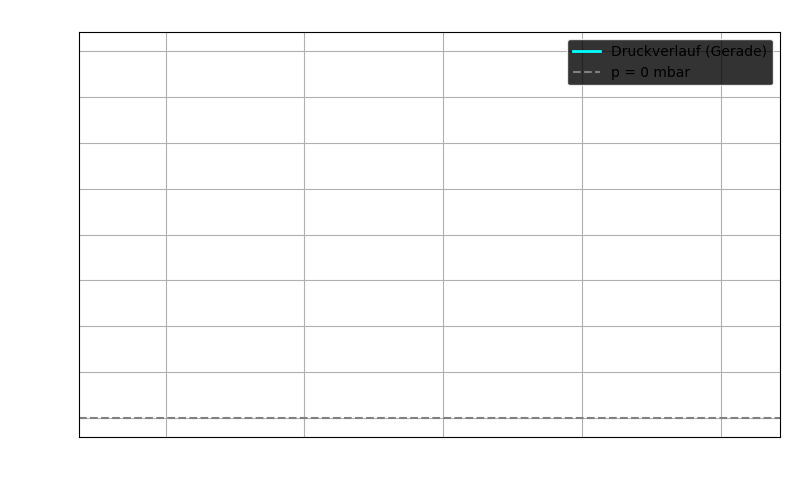

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Daten einlesen
# ===============================
# Zeitwerte (12 Einträge, Spalte C)
col_C = pd.read_excel("Exp7_Dampfdruckkurve_p(T)_Template_2025.xlsx",
                      engine="openpyxl", usecols="C", skiprows=5, nrows=14)
col_C.columns = ["t"]

# Druckwerte (nur 2 Einträge, Spalte I)
col_I = pd.read_excel("Exp7_Dampfdruckkurve_p(T)_Template_2025.xlsx",
                      engine="openpyxl", usecols="I", skiprows=6, nrows=2)
col_I.columns = ["p"]

# ===============================
# Gerade berechnen (Startpunkt → Endpunkt)
# ===============================
t_start = col_C["t"].iloc[0]
t_end = col_C["t"].iloc[-1]
p_start = col_I["p"].iloc[0]
p_end = col_I["p"].iloc[1]

# x-Werte (Zeitbereich)
x_vals = np.linspace(t_start, t_end, 100)
# y-Werte (gerade Verbindung zwischen p_start und p_end)
y_vals = np.linspace(p_start, p_end, 100)

# ===============================
# Plot erstellen
# ===============================
plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, '-', color='aqua', linewidth=2, label="Druckverlauf (Gerade)")

# Markierte Punkte + Werte anzeigen
for t in col_C["t"]:
    # Interpolierter Druck an diesem t-Wert
    p_interp = p_start + (p_end - p_start) * (t - t_start) / (t_end - t_start)
    plt.plot(t, p_interp, 'o', color='aqua')
    plt.text(t, p_interp + 0.05, f"{p_interp:.3f} mbar", ha='center', fontsize=9, color='white')

# Horizontale Linie bei p = 0
plt.axhline(y=0, color='gray', linestyle='--', label="p = 0 mbar")

# Achsen
plt.xlabel("Zeit t [s]", color='white')
plt.ylabel("Druck p [mbar]", color='white')
plt.title("Leckrate", color='white')
plt.tick_params(colors='white')
plt.grid(True)
plt.legend(facecolor='black', edgecolor='white')
plt.tight_layout()
plt.show()

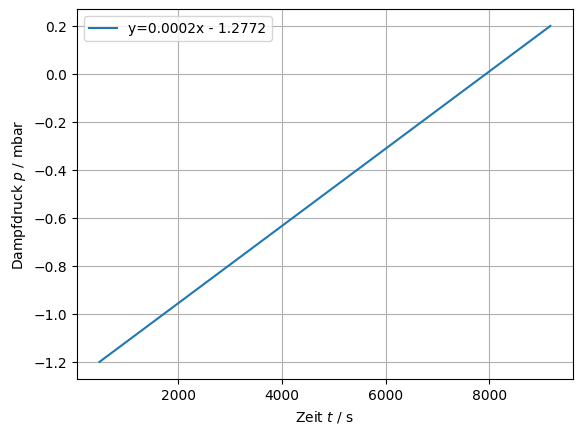

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Daten einlesen
df = pd.read_excel("Exp7_Dampfdruckkurve_p(T)_Template_2025.xlsx", engine="openpyxl", usecols="B:E,I", skiprows=6, nrows=12)

T = df.iloc[:,0]
t = df.iloc[:,1]
p_gel = df.iloc[:,2]
p_kor = df.iloc[:,3]

p_Off = df.iloc[:,4]

# Perform linear regression on the two points
x_data = [t.iloc[0], t.iloc[-1]]
y_data = p_Off.iloc[:2]
slope, intercept, r_value, p_value, std_err = linregress(x_data, y_data)

plt.plot(x_data, y_data, marker="", label=f"y={slope:.4f}x - {-intercept:.4f}")




plt.xlabel("Zeit $t$ / s")
plt.ylabel("Dampfdruck $p$ / mbar")
plt.legend()
plt.grid(True)
plt.show()